CLEANING

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

In [62]:
patients = pd.read_csv('/Users/vinusiya/Desktop/patients.csv') 

In [63]:
# Making a copy and viewing first 6 rows
patients_copy = patients.copy()
patients_copy.head()

,patient_id,first_name,last_name,dob,gender,region,postal_code,insurance_type,chronic_diabetes,chronic_hypertension,registration_date
0,P0000001,Sam,Patel,1982-08-09,Female,Other,J6P 9O0,Employer,False,False,2024-11-30
1,P0000002,Riley,Garcia,1977-02-13,Male,Other,X7L 8B9,Employer,False,True,2019-06-07
2,P0000003,Jamie,Singh,1971-02-25,Female,Mississauga,K4A 7O0,Private,False,False,2024-06-27
3,P0000004,Taylor,Kim,1946-08-15,Male,Oakville,L0K 5R0,Employer,False,False,2023-12-07
4,P0000005,Alex,Patel,1976-11-10,f,Brampton,X0I 0H4,Public,False,True,2019/09/21


In [64]:
# Viewing structure of data
patients_copy.info()

#Need to change DOB and registration date to date format from string

<class 'pandas.DataFrame'>
RangeIndex: 105000 entries, 0 to 104999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   patient_id            105000 non-null  str  
 1   first_name            105000 non-null  str  
 2   last_name             105000 non-null  str  
 3   dob                   103118 non-null  str  
 4   gender                104933 non-null  str  
 5   region                105000 non-null  str  
 6   postal_code           102110 non-null  str  
 7   insurance_type        105000 non-null  str  
 8   chronic_diabetes      105000 non-null  bool 
 9   chronic_hypertension  105000 non-null  bool 
 10  registration_date     105000 non-null  str  
dtypes: bool(2), str(9)
memory usage: 7.4 MB


In [65]:
# Counting number of columns and rows 
print(f'{patients_copy.shape[0]} rows, and {patients_copy.shape[1]} columns')

# Checking number of duplicate rows
print('Duplicate rows:', patients_copy.duplicated().sum())

# Checking number of duplicate patient IDs
print('Duplicate patient IDs:', patients_copy['patient_id'].duplicated().sum())

105000 rows, and 11 columns
Duplicate rows: 0
Duplicate patient IDs: 0


In [66]:
# Triming leading and trailing white space in text columns
text_columns = [
    'first_name',
    'last_name',
    'gender',
    'region',
    'insurance_type'
]

for col in text_columns:
    patients_copy[col] = patients_copy[col].str.strip()

In [67]:
# Standardizing patient IDs from PAT-0000000 to P0000000
patients_copy['patient_id'] = patients_copy['patient_id'].str.replace('PAT-', 'P', regex = False)

# Checking number of duplicated rows
print(patients_copy.duplicated().sum())

# Dropping duplicated rows and counting number of duplicates (duplicates should = 0)
patients_copy = patients_copy.drop_duplicates()
print(patients_copy.duplicated().sum())

0
0


In [ ]:
# Standardize gender entries
gender_clean = {
    'female': 'Female',
    'f': 'Female',
    'woman': 'Female',
    'male': 'Male',
    'm': 'Male',
    'man': 'Male',
    'other': 'Other',
    'unknown': 'Unknown'
}
patients_copy['gender'] = patients_copy['gender'].str.strip().str.lower().map(gender_clean)

# Standardizing date format of dob and registration columns to YYYY-MM-DD
# Missing postal codes are coerced to NaT
patients_copy['dob'] = pd.to_datetime(patients_copy['dob'], format = 'mixed', errors = 'coerce')
# patients_copy['dob'] = patients_copy['dob'].dt.date #Maybe need to take out to keep date for calculations
patients_copy['registration_date'] = pd.to_datetime(patients_copy['registration_date'], format = 'mixed', errors = 'coerce')


In [69]:
# Checking number of missing values
print(patients_copy.isna().sum())

patient_id                 0
first_name                 0
last_name                  0
dob                     1882
gender                    67
region                     0
postal_code             2890
insurance_type             0
chronic_diabetes           0
chronic_hypertension       0
registration_date          0
dtype: int64


In [70]:
# Standardize postal code to 'A1A 1A1' format, and replace invalid postal codes with NA
valid_code = patients_copy['postal_code'].str.strip().str.upper().str.match(r'^[A-Z]\d[A-Z]\s?\d[A-Z]\d$', na = False)
patients_copy['postal_code'] = patients_copy['postal_code'].str.strip().str.upper().str.replace(' ', '', regex = False)
patients_copy['postal_code'] = patients_copy['postal_code'].where(valid_code)
patients_copy['postal_code'] = patients_copy['postal_code'].str[:3] + ' ' + patients_copy['postal_code'].str[3:]


# Removing default postal code A1A 1A1
patients_copy['postal_code'] = patients_copy['postal_code'].replace('A1A 1A1', pd.NA)

# Checking number of missing values
print(patients_copy.isna().sum())

patient_id                 0
first_name                 0
last_name                  0
dob                     1882
gender                    67
region                     0
postal_code             4101
insurance_type             0
chronic_diabetes           0
chronic_hypertension       0
registration_date          0
dtype: int64


In [71]:
# Converting names and gender to title case
patients_copy['first_name'] = patients_copy['first_name'].str.title()
patients_copy['last_name'] = patients_copy['last_name'].str.title()
patients_copy['gender'] = patients_copy['gender'].str.title()

# Filling missing values with 'Unkown' instead of leaving blank strings
patients_copy = patients_copy.fillna('Unknown')

In [72]:
# Final checks
patients_copy.info()
patients_copy.head()

<class 'pandas.DataFrame'>
RangeIndex: 105000 entries, 0 to 104999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   patient_id            105000 non-null  str           
 1   first_name            105000 non-null  str           
 2   last_name             105000 non-null  str           
 3   dob                   105000 non-null  object        
 4   gender                105000 non-null  str           
 5   region                105000 non-null  str           
 6   postal_code           105000 non-null  str           
 7   insurance_type        105000 non-null  str           
 8   chronic_diabetes      105000 non-null  bool          
 9   chronic_hypertension  105000 non-null  bool          
 10  registration_date     105000 non-null  datetime64[us]
dtypes: bool(2), datetime64[us](1), object(1), str(7)
memory usage: 7.4+ MB


,patient_id,first_name,last_name,dob,gender,region,postal_code,insurance_type,chronic_diabetes,chronic_hypertension,registration_date
0,P0000001,Sam,Patel,1982-08-09 00:00:00,Female,Other,J6P 9O0,Employer,False,False,2024-11-30
1,P0000002,Riley,Garcia,1977-02-13 00:00:00,Male,Other,X7L 8B9,Employer,False,True,2019-06-07
2,P0000003,Jamie,Singh,1971-02-25 00:00:00,Female,Mississauga,K4A 7O0,Private,False,False,2024-06-27
3,P0000004,Taylor,Kim,1946-08-15 00:00:00,Male,Oakville,L0K 5R0,Employer,False,False,2023-12-07
4,P0000005,Alex,Patel,1976-11-10 00:00:00,Female,Brampton,X0I 0H4,Public,False,True,2019-09-21


In [73]:
patients_copy.to_csv(os.path.expanduser('~/patients_rough.csv'), index = False)

ANALYSIS OF DATA

Gender Distribution

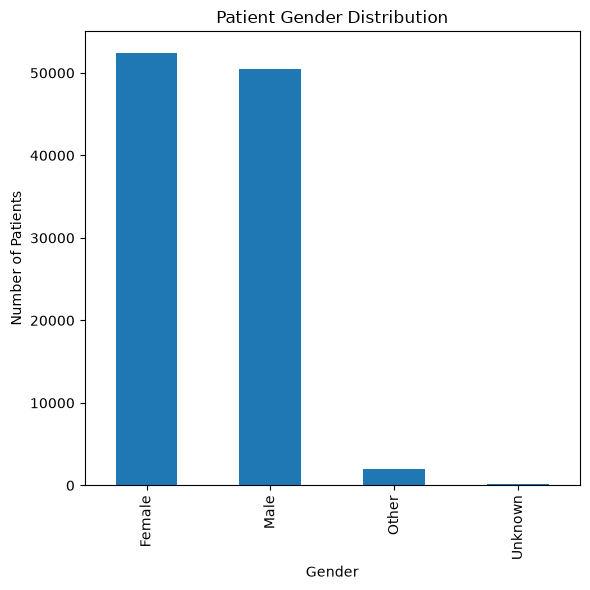

In [87]:
count_gender = patients_copy['gender'].value_counts()

plt.figure(figsize = (6, 6))
count_gender.plot(kind = 'bar')
plt.title('Patient Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

Patient Distribution by Region

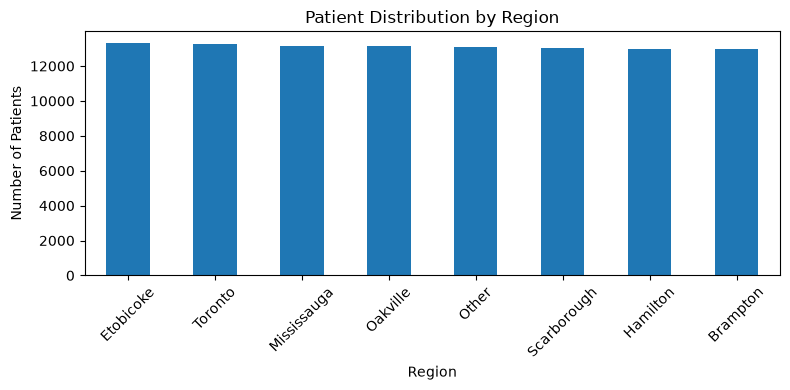

In [75]:
region_counts = patients_copy['region'].value_counts()

plt.figure(figsize = (8, 4))
region_counts.plot(kind = 'bar')
plt.title('Patient Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Number of Patients')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Prevelance of Diabetes in Patients

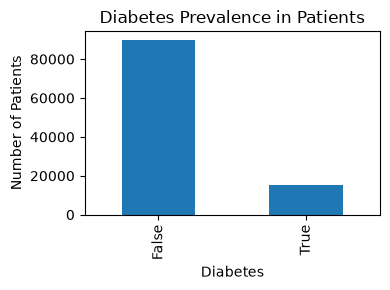

In [76]:
diabetes_counts = patients_copy['chronic_diabetes'].value_counts()

plt.figure(figsize = (4, 3))
diabetes_counts.plot(kind = 'bar')
plt.title('Diabetes Prevalence in Patients')
plt.xlabel('Diabetes')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

Prevelance of Hypertension in Patients

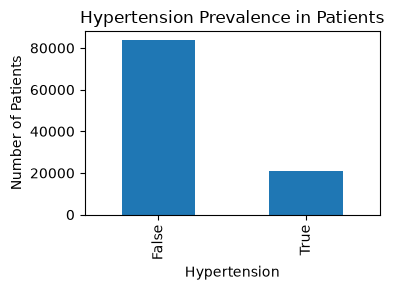

In [77]:
hypertension_counts = patients_copy['chronic_hypertension'].value_counts()

plt.figure(figsize = (4, 3))
hypertension_counts.plot(kind = 'bar')
plt.title('Hypertension Prevalence in Patients')
plt.xlabel('Hypertension')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

Patient Age Groups

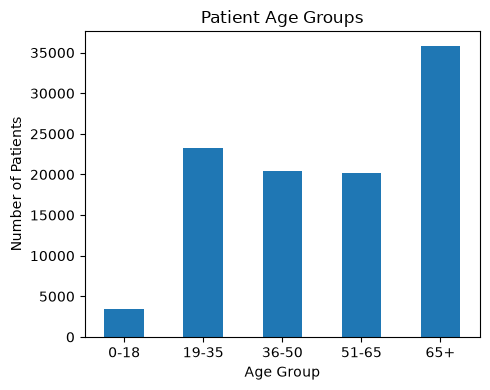

In [84]:
patients_copy['dob'] = pd.to_datetime(patients_copy['dob'], format = 'mixed', errors = 'coerce')

# Calculate age from dob (must happen while dob is still a real datetime)
patients_copy['age'] = (pd.Timestamp.today() - patients_copy['dob']).dt.days / 365.25


patients_age = patients_copy.dropna(subset = ['age']).copy()

patients_age['age_group'] = pd.cut(
    patients_age['age'],
    bins = [0, 18, 35, 50, 65, 120],
    labels = ['0-18', '19-35', '36-50', '51-65', '65+']
)

# count patients in each group, keeping the bins in order (not sorted by size)
age_group_counts = patients_age['age_group'].value_counts().sort_index()

plt.figure(figsize = (5, 4))
age_group_counts.plot(kind = 'bar')
plt.title('Patient Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Insurance Type for Patients by Region

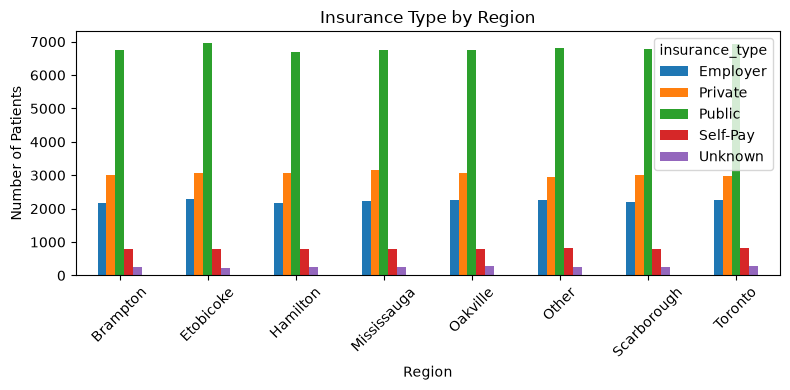

In [82]:
insurance_region = pd.crosstab(
    patients_copy['region'],
    patients_copy['insurance_type']
)

insurance_region.plot(kind = 'bar', figsize = (8, 4))

plt.title('Insurance Type by Region')
plt.xlabel('Region')
plt.ylabel('Number of Patients')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Chronic Condition Prevalence by Age 

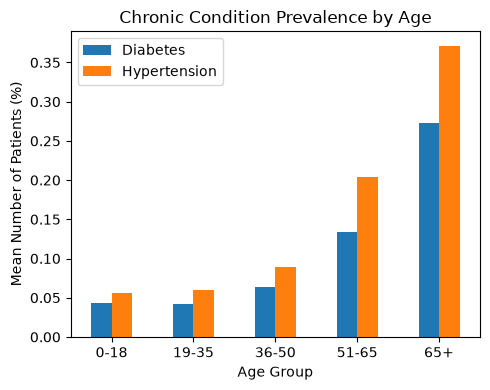

In [83]:
condition_by_age = patients_age.groupby('age_group')[['chronic_diabetes', 'chronic_hypertension']].mean()

condition_by_age.plot(kind = 'bar', figsize = (5, 4))

plt.title('Chronic Condition Prevalence by Age')
plt.xlabel('Age Group')
plt.ylabel('Mean Number of Patients (%)')
plt.xticks(rotation = 0)
plt.legend(['Diabetes', 'Hypertension'])
plt.tight_layout()
plt.show()